In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('../results/sbm_normalized_comparison.csv')

METHODS = [
    's_gd2', 'wrap_python',
    'TorusMDS_smart_1x', 'TorusMDS_smart_100x',
    'TorusMDS_random_1x', 'TorusMDS_random_100x',
]
COLORS  = {
    's_gd2':                 '#4C72B0',
    'wrap_python':           '#55A868',
    'TorusMDS_smart_1x':     '#DD8452',
    'TorusMDS_smart_100x':   '#C44E52',
    'TorusMDS_random_1x':    '#8172B2',
    'TorusMDS_random_100x':  '#CCB974',
}
METRICS = ['stress', 'np_score']
LABELS  = {
    'stress':     'Geodesic normalized stress',
    'distortion': 'Distortion',
    'sgs':        'SGS (Spearman rank corr.)',
    'np_score':   'Neighborhood preservation',
    't_embed':    'Embedding time (s)',
}

# TorusMDS_{smart,random}_{1x,100x} are alpha_aspect runs that jointly learn
# alpha and the aspect ratio (r0, r1); smart/random is the init strategy
# (spectral vs none), 1x/100x is the batch-size multiplier (4096 vs 409600).

data = {m: df[df['method'] == m] for m in METHODS}
print('--- overall ---')
print(df.groupby('method')[METRICS + ['t_embed']].agg(['mean', 'std']).round(4))
print('\n--- graph counts (wrap_python is capped at n <= wrap-python-max-n, so it has fewer) ---')
print(df.groupby('method')['exp_idx'].nunique())


--- overall ---
                      stress         np_score           t_embed          
                        mean     std     mean     std      mean       std
method                                                                   
TorusMDS_random_100x  0.3451  0.0038   0.9999  0.0003  193.1525   74.5276
TorusMDS_random_1x    0.3622  0.0119   0.9999  0.0003    2.1111    0.8347
TorusMDS_smart_100x   0.3451  0.0037   0.9999  0.0003  192.4348   74.2367
TorusMDS_smart_1x     0.3599  0.0111   0.9999  0.0003   70.8161   91.6288
s_gd2                 0.4167  0.0051   0.9999  0.0003   35.2464   45.5186
wrap_python           0.4627  0.0243   0.9998  0.0004  173.9878  199.1980

--- graph counts (wrap_python is capped at n <= wrap-python-max-n, so it has fewer) ---
method
TorusMDS_random_100x    100
TorusMDS_random_1x      100
TorusMDS_smart_100x     100
TorusMDS_smart_1x       100
s_gd2                   100
wrap_python              44
Name: exp_idx, dtype: int64


## Violin plots

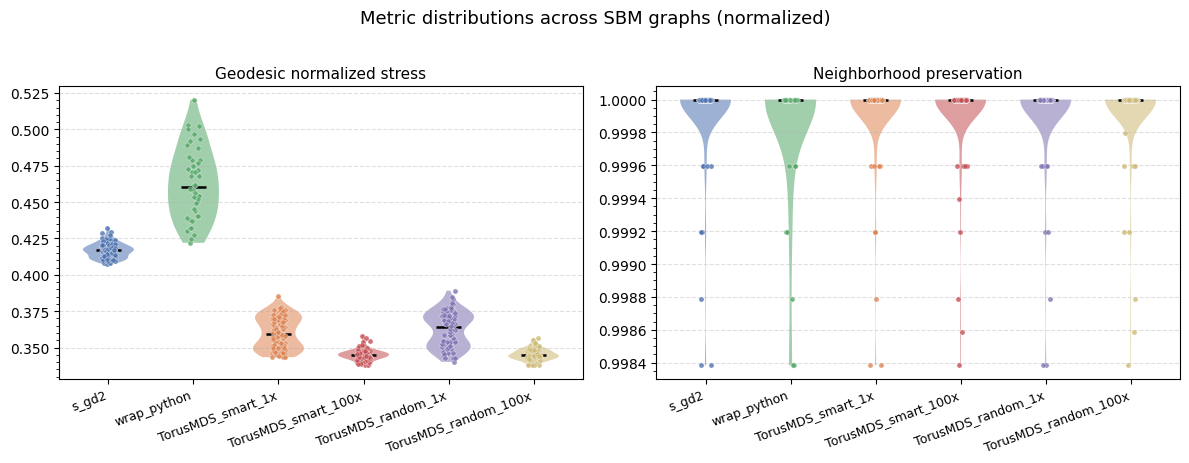

In [2]:
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, metric in zip(axes, METRICS):
    parts = ax.violinplot(
        [data[m][metric].dropna().values for m in METHODS],
        positions=range(len(METHODS)),
        widths=0.6,
        showmedians=True,
        showextrema=False,
    )
    for pc, m in zip(parts['bodies'], METHODS):
        pc.set_facecolor(COLORS[m])
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.8)

    for xi, m in enumerate(METHODS):
        vals = data[m][metric].dropna().values
        jitter = rng.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(xi + jitter, vals, s=14, color=COLORS[m],
                   edgecolors='white', linewidths=0.3, zorder=3, alpha=0.8)

    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(METHODS, fontsize=9, rotation=20, ha='right')
    ax.set_title(LABELS[metric], fontsize=11)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.grid(axis='y', which='major', linestyle='--', alpha=0.4)

fig.suptitle('Metric distributions across SBM graphs (normalized)', fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig('../results/sbm_normalized_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Metrics vs graph size n

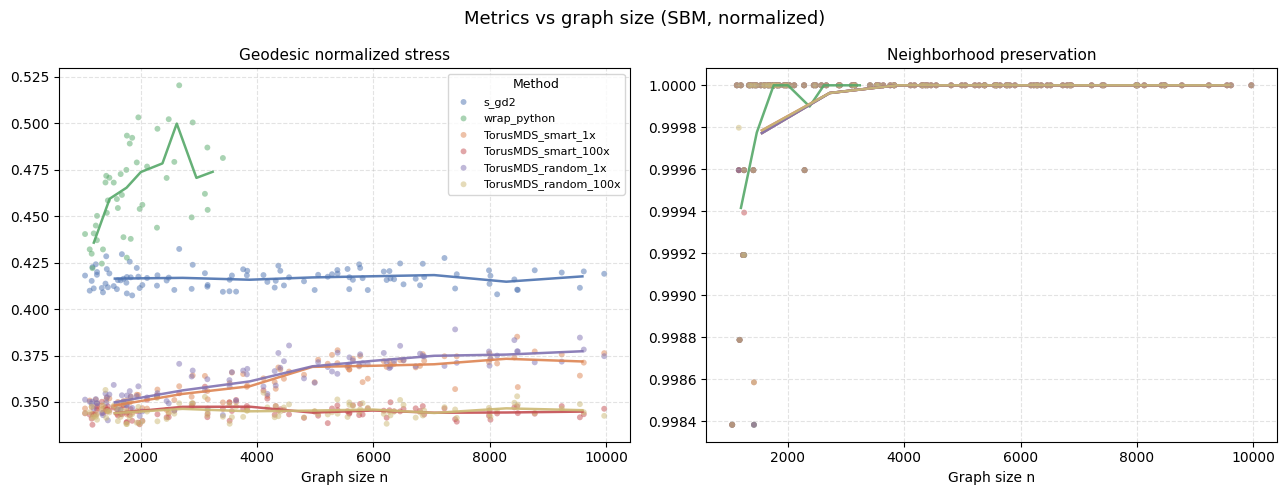

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, METRICS):
    for m in METHODS:
        d = data[m].sort_values('n')
        ax.scatter(d['n'], d[metric], s=18, color=COLORS[m],
                   alpha=0.5, label=m, edgecolors='none')
        bins = pd.cut(d['n'], bins=8)
        trend = d.groupby(bins, observed=True)[metric].mean()
        mids  = d.groupby(bins, observed=True)['n'].mean()
        ax.plot(mids.values, trend.values, color=COLORS[m], linewidth=1.8, alpha=0.9)

    ax.set_xlabel('Graph size n', fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.grid(linestyle='--', alpha=0.35)

axes[0].legend(title='Method', fontsize=8, title_fontsize=9)
fig.suptitle('Metrics vs graph size (SBM, normalized)', fontsize=13)
fig.tight_layout()
plt.savefig('../results/sbm_normalized_metrics_vs_n.png', dpi=150, bbox_inches='tight')
plt.show()

## Metrics vs number of blocks k

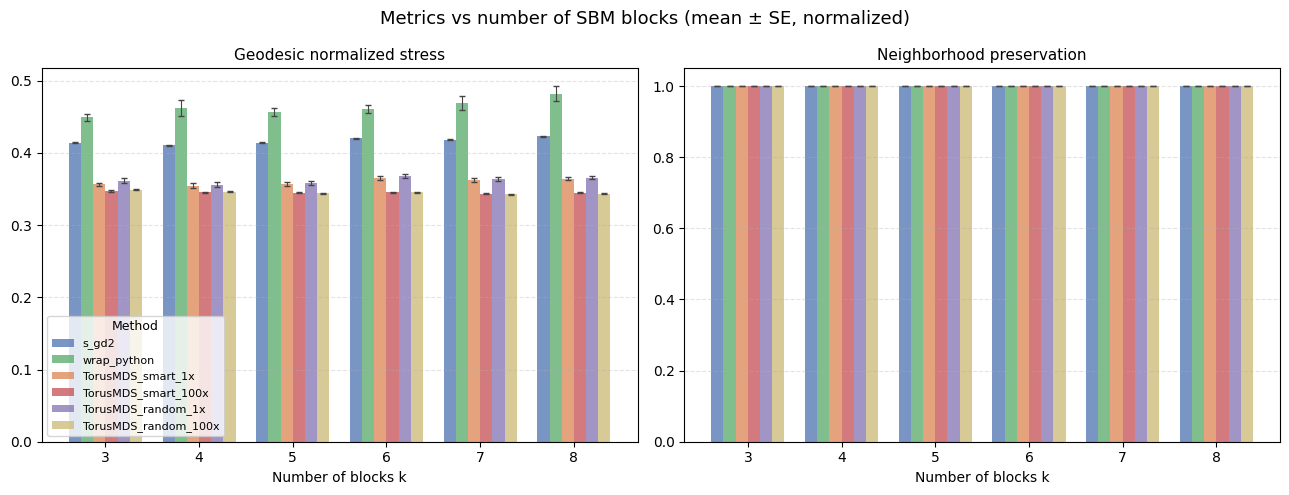

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
w = 0.13   # bar width
ks = sorted(df['k'].unique())

for ax, metric in zip(axes, METRICS):
    for xi, m in enumerate(METHODS):
        means = [data[m][data[m]['k'] == k][metric].mean() for k in ks]
        sems  = [data[m][data[m]['k'] == k][metric].sem()  for k in ks]
        offsets = np.array(ks) + (xi - (len(METHODS) - 1) / 2) * w
        ax.bar(offsets, means, width=w, color=COLORS[m],
               alpha=0.75, label=m, yerr=sems, capsize=2,
               error_kw=dict(elinewidth=0.8, ecolor='#444'))

    ax.set_xticks(ks)
    ax.set_xlabel('Number of blocks k', fontsize=10)
    ax.set_title(LABELS[metric], fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.35)

axes[0].legend(title='Method', fontsize=8, title_fontsize=9)
fig.suptitle('Metrics vs number of SBM blocks (mean ± SE, normalized)', fontsize=13)
fig.tight_layout()
plt.savefig('../results/sbm_normalized_metrics_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

## Running time distributions

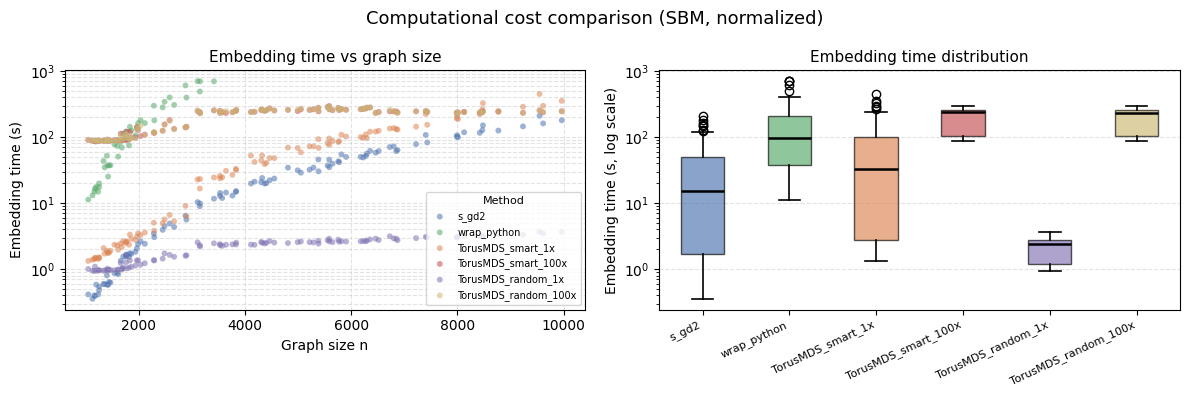

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for m in METHODS:
    d = data[m]
    ax.scatter(d['n'], d['t_embed'], s=18, color=COLORS[m],
               alpha=0.55, label=m, edgecolors='none')
ax.set_xlabel('Graph size n', fontsize=10)
ax.set_ylabel('Embedding time (s)', fontsize=10)
ax.set_yscale('log')
ax.set_title('Embedding time vs graph size', fontsize=11)
ax.legend(title='Method', fontsize=7, title_fontsize=8)
ax.grid(linestyle='--', alpha=0.35, which='both')

ax = axes[1]
bp = ax.boxplot(
    [data[m]['t_embed'].values for m in METHODS],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.8),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)
for patch, m in zip(bp['boxes'], METHODS):
    patch.set_facecolor(COLORS[m])
    patch.set_alpha(0.65)
ax.set_yscale('log')
ax.set_xticks(range(1, len(METHODS) + 1))
ax.set_xticklabels(METHODS, fontsize=8, rotation=25, ha='right')
ax.set_ylabel('Embedding time (s, log scale)', fontsize=10)
ax.set_title('Embedding time distribution', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.yaxis.set_minor_locator(mticker.LogLocator(subs='all', numticks=10))

fig.suptitle('Computational cost comparison (SBM, normalized)', fontsize=13)
fig.tight_layout()
plt.savefig('../results/sbm_normalized_timing.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary table

In [6]:
summary = df.groupby('method')[METRICS + ['t_embed']].agg(['mean', 'median', 'std'])
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.reindex(METHODS).round(4)
summary

,stress_mean,stress_median,stress_std,np_score_mean,np_score_median,np_score_std,t_embed_mean,t_embed_median,t_embed_std
method,,,,,,,,,
s_gd2,0.4167,0.4167,0.0051,0.9999,1.0,0.0003,35.2464,14.9806,45.5186
wrap_python,0.4627,0.4603,0.0243,0.9998,1.0,0.0004,173.9878,95.4622,199.1980
TorusMDS_smart_1x,0.3599,0.3595,0.0111,0.9999,1.0,0.0003,70.8161,32.3315,91.6288
TorusMDS_smart_100x,0.3451,0.3451,0.0037,0.9999,1.0,0.0003,192.4348,236.0979,74.2367
TorusMDS_random_1x,0.3622,0.3643,0.0119,0.9999,1.0,0.0003,2.1111,2.4109,0.8347
TorusMDS_random_100x,0.3451,0.3448,0.0038,0.9999,1.0,0.0003,193.1525,234.9692,74.5276


## Percent change vs s_gd2 baseline

For each method, percent change is computed per matched graph instance against `s_gd2`
(`100 * (method - s_gd2) / s_gd2`), then averaged over the matched instances -- pairing on
`exp_idx` controls for per-graph difficulty, unlike comparing independent means. `wrap_python`
is capped at n <= wrap-python-max-n, so `n_matched` is much smaller for it; treat that column
with that caveat. For `stress`, negative values mean lower (better) stress than `s_gd2`; for
`np_score`, positive values mean better neighbourhood preservation; for `t_embed`, negative
values mean faster embedding.

In [11]:
def paired_pct_change(df, methods, baseline, id_col, metrics):
    """Per-instance percent change vs `baseline`, matched on `id_col`, then aggregated.

    Pairing on the same graph/matrix (rather than comparing independent means)
    controls for per-instance difficulty, which otherwise dominates the variance.
    """
    base = df[df['method'] == baseline].set_index(id_col)
    rows = {}
    for m in methods:
        if m == baseline:
            continue
        other = df[df['method'] == m].set_index(id_col)
        common = base.index.intersection(other.index)
        pct = {'n_matched': len(common)}
        for metric in metrics:
            vals = 100 * (other.loc[common, metric] - base.loc[common, metric]) / base.loc[common, metric]
            pct[f'{metric}_mean_pct'] = vals.mean()
            pct[f'{metric}_median_pct'] = vals.median()
        rows[m] = pct
    return pd.DataFrame(rows).T

pct_change = paired_pct_change(df, METHODS, 's_gd2', 'exp_idx', METRICS + ['t_embed'])
pct_change.round(2)

,n_matched,stress_mean_pct,stress_median_pct,np_score_mean_pct,np_score_median_pct,t_embed_mean_pct,t_embed_median_pct
wrap_python,44.0,11.138076,10.405775,0.000000,0.0,6101.683850,6380.269296
TorusMDS_smart_1x,100.0,-13.611171,-13.409572,0.000000,0.0,110.720097,103.952122
TorusMDS_smart_100x,100.0,-17.160975,-17.337758,0.000405,0.0,4433.361513,1517.143387
TorusMDS_random_1x,100.0,-13.067658,-12.862603,0.000000,0.0,-50.097213,-83.918446
TorusMDS_random_100x,100.0,-17.165591,-17.426630,0.000404,0.0,4448.919045,1555.429511


### Percent-change distributions (strip plot)

Same paired comparison as above, shown as the full per-graph distribution rather than a single
summary number. Each dot is one matched graph; the black tick marks the median. Methods with
fewer than 5 matched instances vs. `s_gd2` are omitted.

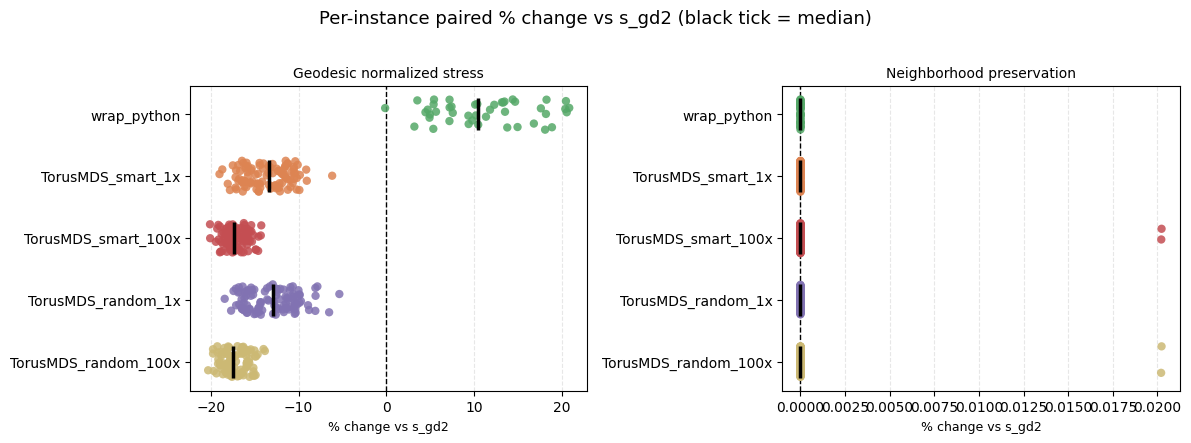

In [2]:
def paired_pct_change_long(df, methods, baseline, id_col, metrics, extra_cols=None):
    """Long-form per-instance percent change vs `baseline`, matched on `id_col`."""
    extra_cols = extra_cols or []
    base = df[df['method'] == baseline].set_index(id_col)
    frames = []
    for m in methods:
        if m == baseline:
            continue
        other = df[df['method'] == m].set_index(id_col)
        common = base.index.intersection(other.index)
        if len(common) == 0:
            continue
        for metric in metrics:
            pct = 100 * (other.loc[common, metric] - base.loc[common, metric]) / base.loc[common, metric]
            frame = pd.DataFrame({'method': m, 'metric': metric, id_col: common, 'pct_change': pct.values})
            for col in extra_cols:
                frame[col] = base.loc[common, col].values
            frames.append(frame)
    return pd.concat(frames, ignore_index=True)


def bootstrap_median_ci(vals, n_boot=2000, ci=95, seed=0):
    rng = np.random.default_rng(seed)
    vals = np.asarray(vals, dtype=float)
    boots = rng.choice(vals, size=(n_boot, len(vals)), replace=True)
    boot_medians = np.median(boots, axis=1)
    lo, hi = np.percentile(boot_medians, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return np.median(vals), lo, hi


MIN_N_FOR_DIST = 5  # below this a histogram/CI isn't meaningful (e.g. wrap_python's capped sample)
_methods_no_base = [m for m in METHODS if m != 's_gd2']
_n_matched = {
    m: len(set(df[df['method'] == m]['exp_idx']) & set(df[df['method'] == 's_gd2']['exp_idx']))
    for m in _methods_no_base
}
plot_methods = [m for m in _methods_no_base if _n_matched[m] >= MIN_N_FOR_DIST]
_skipped = [m for m in _methods_no_base if m not in plot_methods]
if _skipped:
    print(f"Skipping {_skipped} (fewer than {MIN_N_FOR_DIST} matched instances vs s_gd2)")

pct_long = paired_pct_change_long(df, METHODS, 's_gd2', 'exp_idx', METRICS)

import seaborn as sns

groups = [None]
palette = {m: COLORS[m] for m in plot_methods}
fig, axes = plt.subplots(
    1, len(METRICS),
    figsize=(6 * len(METRICS), 0.6 * len(plot_methods) + 1.3 * 1),
    squeeze=False,
)
for gi, gt in enumerate(groups):
    for mi, metric in enumerate(METRICS):
        ax = axes[gi][mi]
        sub = pct_long[pct_long['metric'] == metric]
        
        sub = sub[sub['method'].isin(plot_methods)]
        sns.stripplot(
            data=sub, x='pct_change', y='method', order=plot_methods, hue='method',
            hue_order=plot_methods, palette=palette, size=6, alpha=0.85, jitter=0.25,
            ax=ax, legend=False,
        )
        for yi, m in enumerate(plot_methods):
            vals = sub[sub['method'] == m]['pct_change'].dropna().values
            if len(vals) == 0:
                continue
            ax.scatter(np.median(vals), yi, marker='|', s=500, linewidths=2.5,
                       color='black', zorder=5)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(LABELS[metric], fontsize=10)
        ax.set_xlabel('% change vs s_gd2', fontsize=9)
        ax.set_ylabel('')
        ax.grid(axis='x', linestyle='--', alpha=0.3)
fig.suptitle(
    'Per-instance paired % change vs s_gd2 (black tick = median)',
    fontsize=13, y=1.02,
)
fig.tight_layout()
plt.savefig('../results/sbm_normalized_pct_change_strip.png', dpi=150, bbox_inches='tight')
plt.show()

### Percent-change: median with 95% bootstrap CI

Bootstrap (2000 resamples) 95% CI on the median paired percent change. This is the number to
quote in the paper if you want a single point estimate with uncertainty rather than reporting the
mean, which the earlier table shows is skewed by a few outlier graphs.

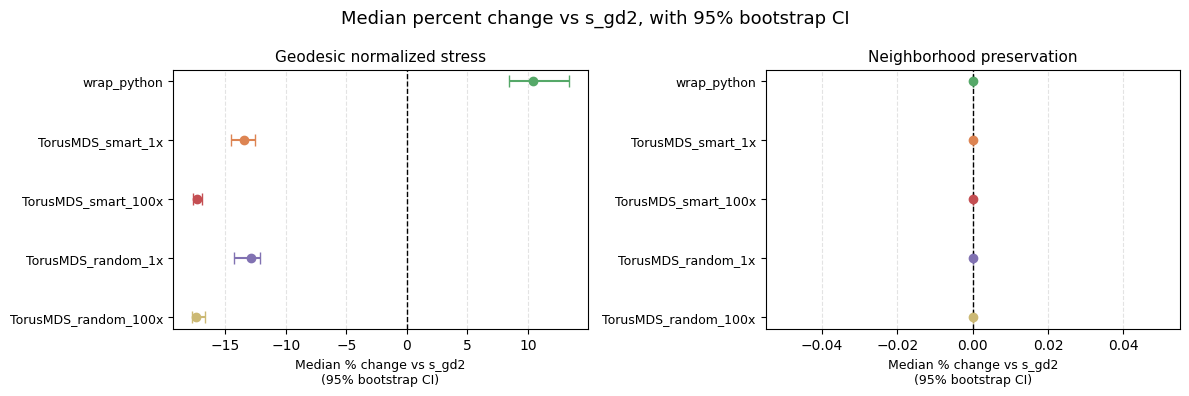

In [3]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(6 * len(METRICS), 0.5 * len(plot_methods) + 1.5 * 1), squeeze=False)
for gi, gt in enumerate(groups):
    for mi, metric in enumerate(METRICS):
        ax = axes[gi][mi]
        sub = pct_long[pct_long['metric'] == metric]
        
        for yi, m in enumerate(plot_methods):
            vals = sub[sub['method'] == m]['pct_change'].dropna().values
            if len(vals) == 0:
                continue
            med, lo, hi = bootstrap_median_ci(vals)
            ax.errorbar(med, yi, xerr=[[med - lo], [hi - med]], fmt='o', color=COLORS[m], capsize=4, markersize=6)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_yticks(range(len(plot_methods)))
        ax.set_yticklabels(plot_methods, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel('Median % change vs s_gd2\n(95% bootstrap CI)', fontsize=9)
        ax.set_title(LABELS[metric], fontsize=11)
        ax.grid(axis='x', linestyle='--', alpha=0.35)
fig.suptitle('Median percent change vs s_gd2, with 95% bootstrap CI', fontsize=13)
fig.tight_layout()
plt.savefig('../results/sbm_normalized_pct_change_ci.png', dpi=150, bbox_inches='tight')
plt.show()

### Symmetric percent change (SPC) distributions (strip plot)

SPC = (method - s_gd2) / max(|method|, |s_gd2|), scaled to a percentage -- unlike the plain
percent change above, it is bounded to [-100, 100] regardless of how small the baseline is.
Same per-instance layout as the percent-change strip plot above.

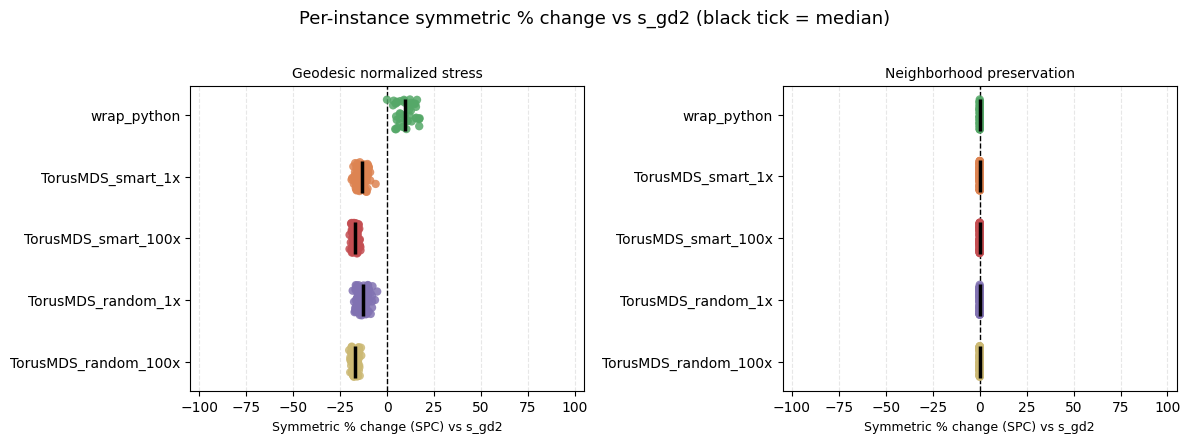

In [4]:
def paired_spc_long(df, methods, baseline, id_col, metrics, extra_cols=None):
    """Per-instance symmetric percent change vs `baseline`, matched on `id_col`.

    SPC = (A - B) / max(|A|, |B|), scaled to a percentage. Bounded to [-100, 100]
    (our metrics are all non-negative), unlike plain percent change, which blows up
    whenever the baseline is small.
    """
    extra_cols = extra_cols or []
    base = df[df['method'] == baseline].set_index(id_col)
    frames = []
    for m in methods:
        if m == baseline:
            continue
        other = df[df['method'] == m].set_index(id_col)
        common = base.index.intersection(other.index)
        if len(common) == 0:
            continue
        for metric in metrics:
            a = other.loc[common, metric]
            b = base.loc[common, metric]
            denom = np.maximum(a.abs(), b.abs())
            spc = 100 * (a - b) / denom
            frame = pd.DataFrame({'method': m, 'metric': metric, id_col: common, 'spc': spc.values})
            for col in extra_cols:
                frame[col] = base.loc[common, col].values
            frames.append(frame)
    return pd.concat(frames, ignore_index=True)


spc_long = paired_spc_long(df, METHODS, 's_gd2', 'exp_idx', METRICS)

fig, axes = plt.subplots(
    1, len(METRICS),
    figsize=(6 * len(METRICS), 0.6 * len(plot_methods) + 1.3 * 1),
    squeeze=False,
)
for gi, gt in enumerate(groups):
    for mi, metric in enumerate(METRICS):
        ax = axes[gi][mi]
        sub = spc_long[spc_long['metric'] == metric]
        
        sub = sub[sub['method'].isin(plot_methods)]
        sns.stripplot(
            data=sub, x='spc', y='method', order=plot_methods, hue='method',
            hue_order=plot_methods, palette=palette, size=6, alpha=0.85, jitter=0.25,
            ax=ax, legend=False,
        )
        for yi, m in enumerate(plot_methods):
            vals = sub[sub['method'] == m]['spc'].dropna().values
            if len(vals) == 0:
                continue
            ax.scatter(np.median(vals), yi, marker='|', s=500, linewidths=2.5,
                       color='black', zorder=5)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_xlim(-105, 105)
        ax.set_title(LABELS[metric], fontsize=10)
        ax.set_xlabel('Symmetric % change (SPC) vs s_gd2', fontsize=9)
        ax.set_ylabel('')
        ax.grid(axis='x', linestyle='--', alpha=0.3)
fig.suptitle(
    'Per-instance symmetric % change vs s_gd2 (black tick = median)',
    fontsize=13, y=1.02,
)
fig.tight_layout()
plt.savefig('../results/sbm_normalized_spc_strip.png', dpi=150, bbox_inches='tight')
plt.show()

### SPC: median with 95% bootstrap CI

Because SPC is bounded, its distribution is far less outlier-driven than the plain percent
change's -- the mean and median are much closer together here (compare to the earlier table).
Median is still shown for direct visual consistency with the percent-change CI plot above.

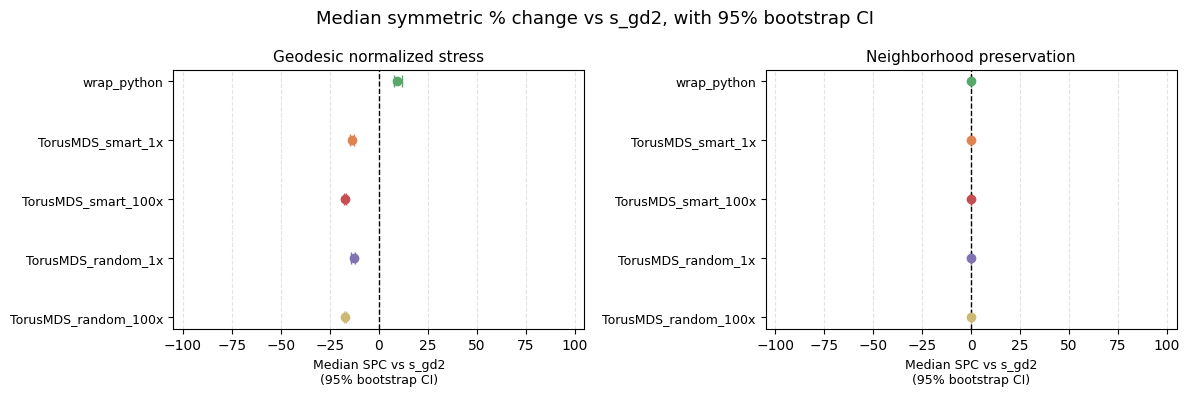

In [5]:
fig, axes = plt.subplots(
    1, len(METRICS),
    figsize=(6 * len(METRICS), 0.5 * len(plot_methods) + 1.5 * 1),
    squeeze=False,
)
for gi, gt in enumerate(groups):
    for mi, metric in enumerate(METRICS):
        ax = axes[gi][mi]
        sub = spc_long[spc_long['metric'] == metric]
        
        for yi, m in enumerate(plot_methods):
            vals = sub[sub['method'] == m]['spc'].dropna().values
            if len(vals) == 0:
                continue
            med, lo, hi = bootstrap_median_ci(vals)
            ax.errorbar(med, yi, xerr=[[med - lo], [hi - med]], fmt='o', color=COLORS[m], capsize=4, markersize=6)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.set_yticks(range(len(plot_methods)))
        ax.set_yticklabels(plot_methods, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlim(-105, 105)
        ax.set_xlabel('Median SPC vs s_gd2\n(95% bootstrap CI)', fontsize=9)
        ax.set_title(LABELS[metric], fontsize=11)
        ax.grid(axis='x', linestyle='--', alpha=0.35)
fig.suptitle(
    'Median symmetric % change vs s_gd2, with 95% bootstrap CI',
    fontsize=13,
)
fig.tight_layout()
plt.savefig('../results/sbm_normalized_spc_ci.png', dpi=150, bbox_inches='tight')
plt.show()

## Runtime: percent change vs s_gd2

The same paired-instance approach as the accuracy metrics above, applied to embedding time.

### Embedding-time percent change (strip plot)

Runtime ratios span orders of magnitude (the `100x` batch-size variants are, unsurprisingly,
~100x slower), so the x-axis uses a symmetric log scale (linear within ±10%, log beyond).
Same per-instance layout as the accuracy strip plots above.

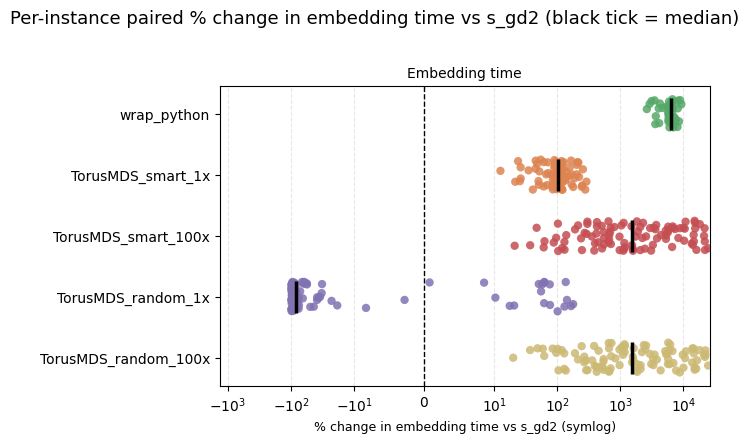

In [6]:
RUNTIME_METRICS = ['t_embed']
pct_long_time = paired_pct_change_long(df, METHODS, 's_gd2', 'exp_idx', RUNTIME_METRICS)

fig, axes = plt.subplots(
    1, 1, figsize=(7, 0.6 * len(plot_methods) + 1.3 * 1), squeeze=False,
)
for gi, gt in enumerate(groups):
    ax = axes[gi][0]
    sub = pct_long_time[pct_long_time['metric'] == 't_embed']
    
    sub = sub[sub['method'].isin(plot_methods)]
    sns.stripplot(
        data=sub, x='pct_change', y='method', order=plot_methods, hue='method',
        hue_order=plot_methods, palette=palette, size=6, alpha=0.85, jitter=0.25,
        ax=ax, legend=False,
    )
    for yi, m in enumerate(plot_methods):
        vals = sub[sub['method'] == m]['pct_change'].dropna().values
        if len(vals) == 0:
            continue
        ax.scatter(np.median(vals), yi, marker='|', s=500, linewidths=2.5, color='black', zorder=5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xscale('symlog', linthresh=10)
    ax.set_title('Embedding time', fontsize=10)
    ax.set_xlabel('% change in embedding time vs s_gd2 (symlog)', fontsize=9)
    ax.set_ylabel('')
    ax.grid(axis='x', linestyle='--', alpha=0.3)
fig.suptitle(
    'Per-instance paired % change in embedding time vs s_gd2 (black tick = median)',
    fontsize=13, y=1.02,
)
fig.tight_layout()
plt.savefig('../results/sbm_normalized_time_pct_change_strip.png', dpi=150, bbox_inches='tight')
plt.show()

### Embedding-time percent change: median with 95% bootstrap CI

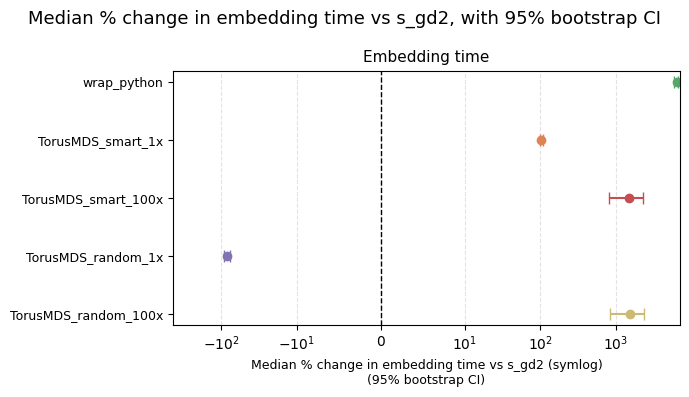

In [7]:
fig, axes = plt.subplots(
    1, 1, figsize=(7, 0.5 * len(plot_methods) + 1.5 * 1), squeeze=False,
)
for gi, gt in enumerate(groups):
    ax = axes[gi][0]
    sub = pct_long_time[pct_long_time['metric'] == 't_embed']
    
    for yi, m in enumerate(plot_methods):
        vals = sub[sub['method'] == m]['pct_change'].dropna().values
        if len(vals) == 0:
            continue
        med, lo, hi = bootstrap_median_ci(vals)
        ax.errorbar(med, yi, xerr=[[med - lo], [hi - med]], fmt='o', color=COLORS[m], capsize=4, markersize=6)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xscale('symlog', linthresh=10)
    ax.set_yticks(range(len(plot_methods)))
    ax.set_yticklabels(plot_methods, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Median % change in embedding time vs s_gd2 (symlog)\n(95% bootstrap CI)', fontsize=9)
    ax.set_title('Embedding time', fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.35)
fig.suptitle(
    'Median % change in embedding time vs s_gd2, with 95% bootstrap CI',
    fontsize=13,
)
fig.tight_layout()
plt.savefig('../results/sbm_normalized_time_pct_change_ci.png', dpi=150, bbox_inches='tight')
plt.show()

### Embedding-time symmetric percent change (SPC) (strip plot)

Same SPC definition as for the accuracy metrics, bounded to [-100, 100] -- useful here since
runtime's plain percent change is heavy-tailed enough to need a log axis above.

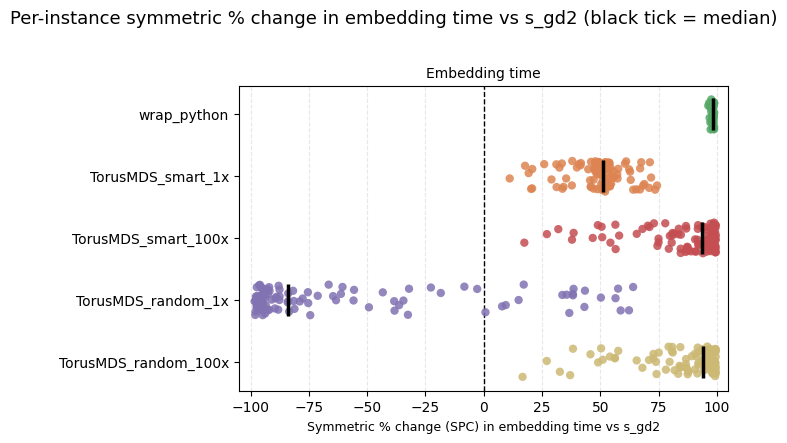

In [8]:
spc_long_time = paired_spc_long(df, METHODS, 's_gd2', 'exp_idx', RUNTIME_METRICS)

fig, axes = plt.subplots(
    1, 1, figsize=(7, 0.6 * len(plot_methods) + 1.3 * 1), squeeze=False,
)
for gi, gt in enumerate(groups):
    ax = axes[gi][0]
    sub = spc_long_time[spc_long_time['metric'] == 't_embed']
    
    sub = sub[sub['method'].isin(plot_methods)]
    sns.stripplot(
        data=sub, x='spc', y='method', order=plot_methods, hue='method',
        hue_order=plot_methods, palette=palette, size=6, alpha=0.85, jitter=0.25,
        ax=ax, legend=False,
    )
    for yi, m in enumerate(plot_methods):
        vals = sub[sub['method'] == m]['spc'].dropna().values
        if len(vals) == 0:
            continue
        ax.scatter(np.median(vals), yi, marker='|', s=500, linewidths=2.5, color='black', zorder=5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlim(-105, 105)
    ax.set_title('Embedding time', fontsize=10)
    ax.set_xlabel('Symmetric % change (SPC) in embedding time vs s_gd2', fontsize=9)
    ax.set_ylabel('')
    ax.grid(axis='x', linestyle='--', alpha=0.3)
fig.suptitle(
    'Per-instance symmetric % change in embedding time vs s_gd2 (black tick = median)',
    fontsize=13, y=1.02,
)
fig.tight_layout()
plt.savefig('../results/sbm_normalized_time_spc_strip.png', dpi=150, bbox_inches='tight')
plt.show()

### Embedding-time SPC: median with 95% bootstrap CI

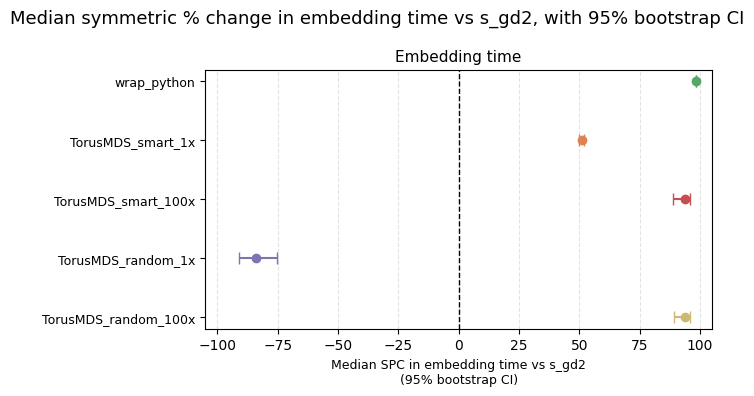

In [9]:
fig, axes = plt.subplots(
    1, 1, figsize=(7, 0.5 * len(plot_methods) + 1.5 * 1), squeeze=False,
)
for gi, gt in enumerate(groups):
    ax = axes[gi][0]
    sub = spc_long_time[spc_long_time['metric'] == 't_embed']
    
    for yi, m in enumerate(plot_methods):
        vals = sub[sub['method'] == m]['spc'].dropna().values
        if len(vals) == 0:
            continue
        med, lo, hi = bootstrap_median_ci(vals)
        ax.errorbar(med, yi, xerr=[[med - lo], [hi - med]], fmt='o', color=COLORS[m], capsize=4, markersize=6)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlim(-105, 105)
    ax.set_yticks(range(len(plot_methods)))
    ax.set_yticklabels(plot_methods, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Median SPC in embedding time vs s_gd2\n(95% bootstrap CI)', fontsize=9)
    ax.set_title('Embedding time', fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.35)
fig.suptitle(
    'Median symmetric % change in embedding time vs s_gd2, with 95% bootstrap CI',
    fontsize=13,
)
fig.tight_layout()
plt.savefig('../results/sbm_normalized_time_spc_ci.png', dpi=150, bbox_inches='tight')
plt.show()

## Reproducibility check: why do the scores look so good?

Every method -- including the `s_gd2`/`wrap_python` baselines, not just TorusMDS -- gets `np_score` >= 0.9998 and stress well under 0.5 across the board. Before trusting that, sanity-check a single sample end to end: regenerate its exact graph from the recorded seed, look at what the shortest-path distance matrix actually looks like, and re-embed it with `TorusMDS_smart_100x` to compare against the recorded row.

In [7]:
import sys

sys.path.insert(0, '.')
from sbm_comparison import sbm_graph_iterator

# Pick one TorusMDS_smart_100x row to regenerate exactly.
row = data['TorusMDS_smart_100x'][
    (data['TorusMDS_smart_100x']['exp_idx'] == 0)
    & data['TorusMDS_smart_100x']['source_shard'].str.contains('1000_3000_shard_1')
].iloc[0]
print(row[['exp_idx', 'k', 'n', 'stress', 'pointwise_stress', 'alpha', 'r0_fit', 'r1_fit', 'source_shard']])

# source_shard encodes N_MIN/N_MAX/SHARD; seed = SEED_BASE(0) + SHARD (run_embed_array.sbatch),
# and exp_idx is the graph's position within sbm_graph_iterator's sequential draw from that seed
# -- both graph generation AND the embedding SGD are seeded from this same value
# (modules/experiment_runner.py's run_embeddings passes `seed` through to both). The generator
# is lazy and stateful over the shared `rng`, so advancing it to exp_idx means consuming (and
# discarding) every earlier draw, not just jumping to the target index.
seed = 1
rng = np.random.default_rng(seed)
for graph_rec in sbm_graph_iterator(n_graphs=int(row['exp_idx']) + 1, n_min=1000, n_max=3000,
                                     k_min=3, k_max=8, rng=rng):
    pass  # keep advancing; graph_rec ends up holding exp_idx == row['exp_idx']

G = graph_rec.graph
print(f"\nRegenerated graph: n={G.number_of_nodes()}, k={graph_rec.meta['k']}  "
      f"(expected n={int(row['n'])}, k={int(row['k'])})")

exp_idx                                                             0
k                                                                   7
n                                                                1754
stress                                                       0.338933
pointwise_stress                                             0.379352
alpha                                                        4.514925
r0_fit                                                       1.001241
r1_fit                                                       0.998761
source_shard        results/sbm_normalized_1000_3000_shard_1_compa...
Name: 1, dtype: object



Regenerated graph: n=1754, k=7  (expected n=1754, k=7)


In [8]:
from modules.graphio import apsp_distance_matrix

D, _ = apsp_distance_matrix(G)
print(f"avg degree = {2 * G.number_of_edges() / G.number_of_nodes():.1f}, diameter = {D.max():.0f}")

vals, counts = np.unique(D[np.triu_indices_from(D, k=1)], return_counts=True)
total = counts.sum()
for v, c in zip(vals, counts):
    print(f"  distance {v:.0f}: {c:>9,d} pairs  ({100 * c / total:5.2f}%)")

avg degree = 149.5, diameter = 3
  distance 1:   131,082 pairs  ( 8.53%)
  distance 2: 1,406,278 pairs  (91.47%)
  distance 3:        21 pairs  ( 0.00%)


**This is the actual answer, not just this one sample**: `p_in=0.3`/`p_out=0.05` are fixed constants regardless of `n` or `k` (see `generate_sbm` in `sbm_comparison.py`), so average degree scales linearly with block size (~150 here). At that density the graph is nearly complete -- the shortest-path distance matrix collapses to 3 distinct values, with 91%+ of all pairs at distance exactly 2. There just isn't much dynamic range left for *any* embedding to get wrong, which is why `np_score`/`stress` are uniformly good across every method above, including the `s_gd2`/`wrap_python` baselines -- it's a property of this graph family's fixed edge probabilities, not something specific to TorusMDS.

Next: re-embed this exact graph with `TorusMDS_smart_100x` and compare against the recorded row (~3 min -- `100x` batch size is the slow variant).

In [9]:
from modules.initialization import find_fundamental_torus_directions
from modules.experiment_runner import embed_torus_mds_aspect
from modules.metrics import estimate_alpha, geodesic_stress, pointwise_geodesic_stress
from modules.geometry import torus_distance

spectral_result = find_fundamental_torus_directions(D / D.max())
X, alpha_fit, r0_fit, r1_fit = embed_torus_mds_aspect(
    D, init_mode="smart", batch_multiplier=100, spectral_result=spectral_result,
    max_iters=2000, seed=seed, stress_mode="normalized",
)

# Match compute_metrics.py's evaluation exactly: subsample to 100 points (its default
# metric_subsample), re-estimate alpha on the subsample holding r0/r1 fixed, then stress.
rng_sub = np.random.default_rng(42)
idx = rng_sub.choice(X.shape[0], min(100, X.shape[0]), replace=False)
X_s, D_s = X[idx], D[np.ix_(idx, idx)]
alpha_eval = estimate_alpha(X_s, D_s, r0=r0_fit, r1=r1_fit)
geod = lambda p, q, a=alpha_eval, r0=r0_fit, r1=r1_fit: a * torus_distance(p, q, r0=r0, r1=r1)
stress = geodesic_stress(X_s, D_s, geod)
pstress = pointwise_geodesic_stress(X_s, D_s, geod)

print(f"training:   alpha={alpha_fit:.4f}  r0={r0_fit:.6f}  r1={r1_fit:.6f}")
print(f"recomputed: alpha={alpha_eval:.4f}  stress={stress:.4f}  pointwise_stress={pstress:.4f}")
print(f"CSV row:    alpha={row['alpha']:.4f}  stress={row['stress']:.4f}  "
      f"pointwise_stress={row['pointwise_stress']:.4f}  r0_fit={row['r0_fit']:.6f}  r1_fit={row['r1_fit']:.6f}")
print("\n(small differences vs. the CSV are expected -- SGD on a random minibatch schedule\n"
      " is sensitive to floating-point rounding, so re-running isn't bit-exact even from\n"
      " the same seed; the graph itself regenerates identically, which is the part that matters.)")

training:   alpha=1.4305  r0=1.005537  r1=0.994493
recomputed: alpha=4.5092  stress=0.3375  pointwise_stress=0.3749
CSV row:    alpha=4.5149  stress=0.3389  pointwise_stress=0.3794  r0_fit=1.001241  r1_fit=0.998761

(small differences vs. the CSV are expected -- SGD on a random minibatch schedule
 is sensitive to floating-point rounding, so re-running isn't bit-exact even from
 the same seed; the graph itself regenerates identically, which is the part that matters.)


## Drawing the re-embedded sample

Colored by ground-truth SBM block membership. A cluster that touches the boundary wraps around and reappears on the opposite edge -- that's the flat torus's fundamental domain, not a duplicate.

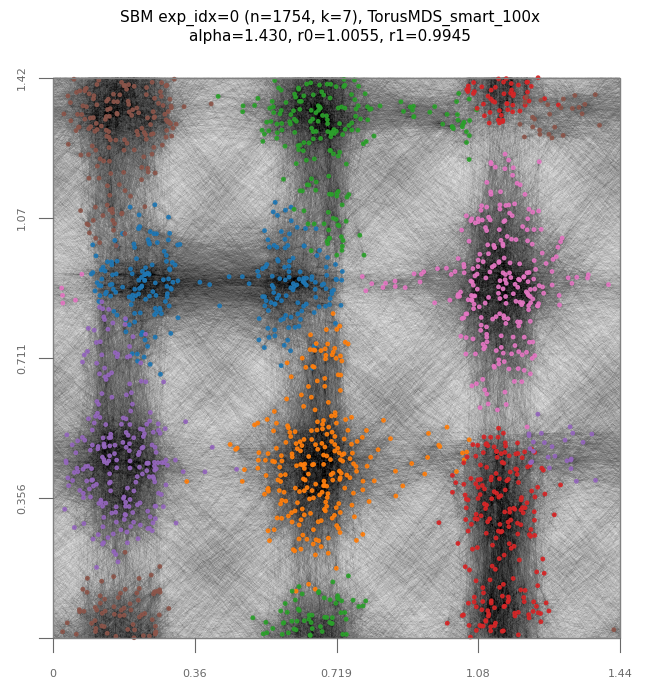

In [10]:
from types import SimpleNamespace
from modules.visualization import plot_embedding_with_torus_edges

blocks = np.array([G.nodes[node]['block'] for node in G.nodes()])
torus = SimpleNamespace(alpha_=alpha_fit, r0_=r0_fit, r1_=r1_fit, theta_=np.pi / 2)

fig, ax = plt.subplots(figsize=(7, 7))
plot_embedding_with_torus_edges(
    X=X, G=G, torus=torus, ax=ax,
    s=6, edge_alpha=0.02, edge_lw=0.3,
    colors=blocks, cmap='tab10', vmin=0, vmax=9,
)
ax.set_title(f"SBM exp_idx={int(row['exp_idx'])} (n={G.number_of_nodes()}, k={graph_rec.meta['k']}), "
             f"TorusMDS_smart_100x\nalpha={alpha_fit:.3f}, r0={r0_fit:.4f}, r1={r1_fit:.4f}",
             fontsize=11)
fig.tight_layout()
plt.savefig('../results/sbm_normalized_smart100x_sample.png', dpi=150, bbox_inches='tight')
plt.show()